<div class="alert alert-block alert-info"> 
    <center><h1 "> Tarea 2: Fundamentos de Procesamiento de Imágenes - IEE2714</h1> </center>
</div>
    <!-- <b></b>     -->

<!-- 
<div class="alert alert-block alert-success"> Use green boxes sparingly, and only for some specific purpose that the other boxes can't cover. For example, if you have a lot of related content to link to, maybe you decide to use green boxes for related links from each section of a notebook. </div>

<div class="alert alert-block alert-warning"> Use yellow boxes for examples that are not inside code cells, or use for mathematical formulas if needed. </div>

<div class="alert alert-block alert-danger"> In general, just avoid the red boxes. </div>

############# Markdown parser in Sphinx ##################

<div class="admonition note"> <p class="admonition-title">Note</p> <p>You should note that the title will be automatically capitalized.</p> </div>

<div class="admonition danger"> <p class="admonition-title">Don't try this at home</p> <p>...</p> </div>
 -->
<!-- <div class="admonition important"> <p>This is an admonition box without a title.</p> </div> -->

<div class="alert alert-block alert-success"> <b> Nombre de estudiante: </b> Tomás Ferrada Contreras</div>


<div style="border-left: 6px solid #0ea5e9; background:#f0f9ff; padding:10px 12px; border-radius:8px; margin-bottom:8px;">
  <b>Problema 1.</b>
</div>




<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

=== Sigmas Óptimos Encontrados (Paso Δσ = 0.05) ===
Fondo    (I=0.15): σ* = 1.75
Cuadrado (I=0.45): σ* = 1.35
Círculo  (I=0.80): σ* = 1.45
Global           : σ* = 1.50

=== Resultados Comparativos de RMSE ===
Global Óptimo (σ=1.50): 0.02381
Adaptativo continuo                : 0.02364

=== Evaluación Puntual de Píxeles (Pregunta 4) ===
-> Píxel en Fondo (10, 10):
   μ_hat = 0.150
   σ     = 1.750
   Kernel: Tamaño = 13x13
           Coeficiente Central = 0.0520
           Suma de Coeficientes = 1.000000

-> Píxel en Cuadrado (100, 100):
   μ_hat = 0.472
   σ     = 1.356
   Kernel: Tamaño = 11x11
           Coeficiente Central = 0.0865
           Suma de Coeficientes = 1.000000

-> Píxel en Círculo (128, 128):
   μ_hat = 0.795
   σ     = 1.449
   Kernel: Tamaño = 11x11
           Coeficiente Central = 0.0759
           Suma de Coeficientes = 1.000000

-> Píxel en Cerca Frontera Cuadrado/Círculo (128, 159):
   μ_hat = 0.648
   σ     = 1.406
   Kernel: Tamaño = 11x11
           Coeficient

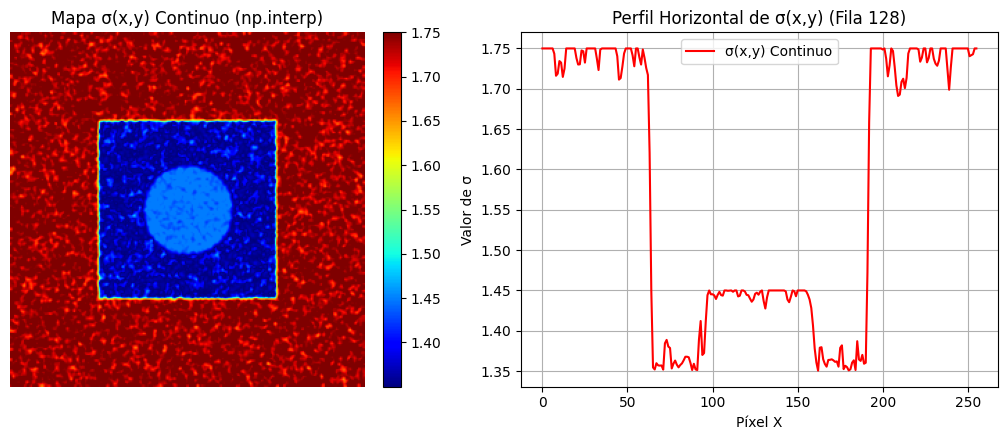

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. GENERACIÓN DE LA IMAGEN SINTÉTICA Y RUIDO POISSON
# ---------------------------------------------------------
N_size = 256
x = np.full((N_size, N_size), 0.15, dtype=np.float64)

# Cuadrado centrado de 128x128
sq_slice = slice(64, 192)
x[sq_slice, sq_slice] = 0.45

# Círculo centrado de radio 32
center_y, center_x = 128, 128
r = 32
yy, xx = np.ogrid[:N_size, :N_size]
circle_mask_bool = (xx - center_x) ** 2 + (yy - center_y) ** 2 <= r**2
x[circle_mask_bool] = 0.80

# Máscaras
mask_circle = circle_mask_bool
mask_square = np.zeros((N_size, N_size), dtype=bool)
mask_square[sq_slice, sq_slice] = True
mask_square[mask_circle] = False

mask_background = ~(np.zeros((N_size, N_size), dtype=bool))
mask_background[sq_slice, sq_slice] = False

# Generación del ruido Poisson con semilla fija
np.random.seed(42)
N = 40
y = np.random.poisson(N * x) / float(N)


# ---------------------------------------------------------
# 2. FUNCIONES DE FILTRADO Y MAPEO
# ---------------------------------------------------------
def create_gaussian_kernel(sigma: float, size: int = None) -> np.ndarray:
    if sigma <= 0:
        raise ValueError("Sigma debe ser mayor que 0.")
    if size is None:
        radius = int(np.ceil(3 * sigma))
        size = 2 * radius + 1
    elif size % 2 == 0:
        raise ValueError("El tamaño del kernel debe ser impar.")

    center = size // 2
    yy, xx = np.mgrid[-center : center + 1, -center : center + 1]
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel /= kernel.sum()
    return kernel


def apply_gaussian_filter(img: np.ndarray, sigma: float) -> np.ndarray:
    kernel = create_gaussian_kernel(sigma)
    pad_size = kernel.shape[0] // 2
    img_padded = np.pad(img, pad_size, mode="reflect")
    filtered_img = np.zeros_like(img)
    k_size = kernel.shape[0]
    H, W = img.shape

    for i in range(H):
        for j in range(W):
            region = img_padded[i : i + k_size, j : j + k_size]
            filtered_img[i, j] = np.sum(region * kernel)
    return filtered_img


def calculate_rmse(
    img_ref: np.ndarray, img_filtered: np.ndarray, mask: np.ndarray = None
) -> float:
    if mask is None:
        diff = img_ref - img_filtered
    else:
        diff = (img_ref - img_filtered)[mask]
    return np.sqrt(np.mean(diff**2))


# Mapeo continuo F(mu_hat) corregido (Soluciona Punto 6)
def map_intensity_to_sigma_continuous(
    mu_hat: np.ndarray, mu_nodes: list, sigma_nodes: list
) -> np.ndarray:
    """Interpola linealmente mu_hat para evitar saltos abruptos y halos en sigma(x,y)."""
    return np.interp(mu_hat, mu_nodes, sigma_nodes)


def apply_adaptive_gaussian_filter(
    img_noisy: np.ndarray, sigma_map: np.ndarray
) -> np.ndarray:
    H, W = img_noisy.shape
    max_sigma = np.max(sigma_map)
    max_pad = int(np.ceil(3 * max_sigma))
    img_padded = np.pad(img_noisy, max_pad, mode="reflect")
    output_img = np.zeros_like(img_noisy)

    for i in range(H):
        for j in range(W):
            sig_local = sigma_map[i, j]
            r_local = int(np.ceil(3 * sig_local))
            k_size_local = 2 * r_local + 1
            kernel_local = create_gaussian_kernel(
                sig_local, size=k_size_local
            )

            i_pad, j_pad = i + max_pad, j + max_pad
            region = img_padded[
                i_pad - r_local : i_pad + r_local + 1,
                j_pad - r_local : j_pad + r_local + 1,
            ]
            output_img[i, j] = np.sum(region * kernel_local)
    return output_img


# ---------------------------------------------------------
# 3. EXPERIMENTACIÓN: BÚSQUEDA FINA Y APLICACIÓN ADAPTATIVA
# ---------------------------------------------------------
# Paso de sigma = 0.05 para mayor precisión
sigmas = np.arange(0.1, 3.55, 0.05)

rmse_global, rmse_bg, rmse_sq, rmse_circ = [], [], [], []

for s in sigmas:
    y_filt = apply_gaussian_filter(y, sigma=s)
    rmse_global.append(calculate_rmse(x, y_filt))
    rmse_bg.append(calculate_rmse(x, y_filt, mask_background))
    rmse_sq.append(calculate_rmse(x, y_filt, mask_square))
    rmse_circ.append(calculate_rmse(x, y_filt, mask_circle))

sigmas_opt = {
    "bg": sigmas[np.argmin(rmse_bg)],
    "sq": sigmas[np.argmin(rmse_sq)],
    "circ": sigmas[np.argmin(rmse_circ)],
    "global": sigmas[np.argmin(rmse_global)],
}

print("=== Sigmas Óptimos Encontrados (Paso Δσ = 0.05) ===")
print(f"Fondo    (I=0.15): σ* = {sigmas_opt['bg']:.2f}")
print(f"Cuadrado (I=0.45): σ* = {sigmas_opt['sq']:.2f}")
print(f"Círculo  (I=0.80): σ* = {sigmas_opt['circ']:.2f}")
print(f"Global           : σ* = {sigmas_opt['global']:.2f}\n")

# Estimación auxiliar mu_hat con sigma_aux = 1.0
mu_hat = apply_gaussian_filter(y, sigma=1.0)

# Aplicación de F continua con np.interp
mu_nodes = [0.15, 0.45, 0.80]
sigma_nodes = [sigmas_opt["bg"], sigmas_opt["sq"], sigmas_opt["circ"]]
sigma_map_cont = map_intensity_to_sigma_continuous(
    mu_hat, mu_nodes, sigma_nodes
)

# Filtrado Adaptativo
y_adapt = apply_adaptive_gaussian_filter(y, sigma_map_cont)
y_best_global = apply_gaussian_filter(y, sigma=sigmas_opt["global"])

print("=== Resultados Comparativos de RMSE ===")
print(f"Global Óptimo (σ={sigmas_opt['global']:.2f}): {calculate_rmse(x, y_best_global):.5f}")
print(f"Adaptativo continuo                : {calculate_rmse(x, y_adapt):.5f}\n")

# ---------------------------------------------------------
# 4. EVALUACIÓN PUNTUAL (PREGUNTA GUIADA 4)
# ---------------------------------------------------------
pixels_to_eval = {
    "Fondo (10, 10)": (10, 10),
    "Cuadrado (100, 100)": (100, 100),
    "Círculo (128, 128)": (128, 128),
    "Cerca Frontera Cuadrado/Círculo (128, 159)": (128, 159),
}

print("=== Evaluación Puntual de Píxeles (Pregunta 4) ===")
for name, (r_idx, c_idx) in pixels_to_eval.items():
    mu_val = mu_hat[r_idx, c_idx]
    sig_val = sigma_map_cont[r_idx, c_idx]
    k_eval = create_gaussian_kernel(sig_val)
    center_k = k_eval.shape[0] // 2

    print(f"-> Píxel en {name}:")
    print(f"   μ_hat = {mu_val:.3f}")
    print(f"   σ     = {sig_val:.3f}")
    print(f"   Kernel: Tamaño = {k_eval.shape[0]}x{k_eval.shape[0]}")
    print(f"           Coeficiente Central = {k_eval[center_k, center_k]:.4f}")
    print(f"           Suma de Coeficientes = {k_eval.sum():.6f}\n")

# Visualización del Mapa σ(x,y) continuo y perfil de transición
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im = axes[0].imshow(sigma_map_cont, cmap="jet")
axes[0].set_title("Mapa σ(x,y) Continuo (np.interp)")
axes[0].axis("off")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(sigma_map_cont[128, :], "r-", label="σ(x,y) Continuo")
axes[1].set_title("Perfil Horizontal de σ(x,y) (Fila 128)")
axes[1].set_xlabel("Píxel X")
axes[1].set_ylabel("Valor de σ")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #0ea5e9; background:#f0f9ff; padding:10px 12px; border-radius:8px; margin-bottom:8px;">
  <b>Problema 2. </b>
</div>


<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

--- Evolución de RMSE ---


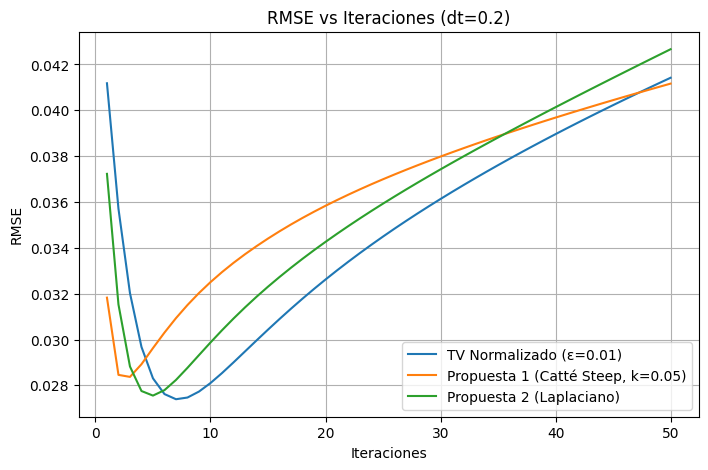

Mejor RMSE TV: 0.0274 (Iter 7)
Mejor RMSE P1: 0.0284 (Iter 3)
Mejor RMSE P2: 0.0276 (Iter 5)

--- Evaluación de Píxeles (Iteración 1, Prop 1) ---

Homogéneo (50,50):
  u_t = 0.7040
  Diferencias: N=0.1597, S=0.1198, E=0.1292, W=0.1195
  Coeficientes en caras: cN=0.8064, cS=0.8825, cE=0.8938, cW=0.7836
  c central = 0.9880
  u_t+1 = 0.7927

Borde (100,150):
  u_t = 0.8338
  Diferencias: N=-0.0150, S=0.0430, E=-0.0865, W=0.0148
  Coeficientes en caras: cN=0.8808, cS=0.8914, cE=0.8470, cW=0.8884
  c central = 0.8276
  u_t+1 = 0.8269


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import skimage

# ---------------------------------------------------------
# 1. IMAGEN RUIDOSA Y SETUP
# ---------------------------------------------------------

#Voy a usar la imagen de la camara que habia en la capsula de codigo yq aue no encontre una imagen
#anexada a la Tarea

image_clean = skimage.data.camera().astype(np.float64) / 255.0
np.random.seed(42)
sigma_noise = 0.05
image_noisy = np.clip(image_clean + np.random.normal(0, sigma_noise, image_clean.shape), 0, 1)

def calculate_rmse(img_ref, img_eval):
    return np.sqrt(np.mean((img_ref - img_eval) ** 2))

# ---------------------------------------------------------
# 2. COEFICIENTES DE DIFUSIÓN CORREGIDOS
# ---------------------------------------------------------
def coeff_tv_normalized(u: np.ndarray, epsilon: float = 1e-2) -> np.ndarray:
    """
    TV Normalizado: c = epsilon / sqrt(|Grad(u)|^2 + epsilon^2)
    Garantiza c_max <= 1. El factor 1/epsilon se absorbe requiriendo más iteraciones
    para mantener la estabilidad con dt = 0.2.
    """
    grad_y, grad_x = np.gradient(u)
    grad_sq = grad_y**2 + grad_x**2
    return epsilon / np.sqrt(grad_sq + epsilon**2)

def coeff_prop1_catte_steep(u: np.ndarray, k: float = 0.05, sigma_pre: float = 0.5) -> np.ndarray:
    """
    Propuesta 1 (Nueva): Variante de Catté et al. con decaimiento abrupto.
    c = 1 / (1 + (|Grad(u_smooth)| / k)^4)
    Usa pre-suavizado para robustez al ruido y un exponente 4 para retener bordes más nítidos.
    """
    u_smooth = skimage.filters.gaussian(u, sigma=sigma_pre)
    grad_y, grad_x = np.gradient(u_smooth)
    grad_mag = np.sqrt(grad_y**2 + grad_x**2)
    return 1.0 / (1.0 + (grad_mag / k)**4)

def coeff_prop2_laplacian(u: np.ndarray, k_grad: float = 0.08, k_lap: float = 0.04, sigma_pre: float = 0.8) -> np.ndarray:
    """Propuesta 2: Combinación Gradiente + Laplaciano estabilizado."""
    u_smooth = skimage.filters.gaussian(u, sigma=sigma_pre)
    grad_y, grad_x = np.gradient(u_smooth)
    grad_mag = np.sqrt(grad_y**2 + grad_x**2)
    laplacian = skimage.filters.laplace(u_smooth)
    E = grad_mag / k_grad + np.abs(laplacian) / k_lap
    return np.exp(-E)

# ---------------------------------------------------------
# 3. ESQUEMA DE DIFUSIÓN ANISOTRÓPICA
# ---------------------------------------------------------
def anisotropic_diffusion_step(u, coeff_fn, dt, coeff_kwargs):
    c = coeff_fn(u, **coeff_kwargs)
    diff_N = np.pad(u[:-1, :], ((1, 0), (0, 0)), mode="edge") - u
    diff_S = np.pad(u[1:, :], ((0, 1), (0, 0)), mode="edge") - u
    diff_E = np.pad(u[:, 1:], ((0, 0), (0, 1)), mode="edge") - u
    diff_W = np.pad(u[:, :-1], ((0, 0), (1, 0)), mode="edge") - u
    
    c_N = 0.5 * (c + np.pad(c[:-1, :], ((1, 0), (0, 0)), mode="edge"))
    c_S = 0.5 * (c + np.pad(c[1:, :], ((0, 1), (0, 0)), mode="edge"))
    c_E = 0.5 * (c + np.pad(c[:, 1:], ((0, 0), (0, 1)), mode="edge"))
    c_W = 0.5 * (c + np.pad(c[:, :-1], ((0, 0), (1, 0)), mode="edge"))
    
    flux = c_N * diff_N + c_S * diff_S + c_E * diff_E + c_W * diff_W
    u_next = u + dt * flux
    return u_next, c, diff_N, diff_S, diff_E, diff_W, c_N, c_S, c_E, c_W

# ---------------------------------------------------------
# 4. EXPERIMENTO: SEGUIMIENTO RMSE vs ITERACIONES
# ---------------------------------------------------------
print("--- Evolución de RMSE ---")
max_iters = 50
dt = 0.2

u_tv = image_noisy.copy()
u_p1 = image_noisy.copy()
u_p2 = image_noisy.copy()

rmse_tv_hist, rmse_p1_hist, rmse_p2_hist = [], [], []

for i in range(max_iters):
    u_tv, _, _, _, _, _, _, _, _, _ = anisotropic_diffusion_step(u_tv, coeff_tv_normalized, dt, {"epsilon": 0.01})
    u_p1, _, _, _, _, _, _, _, _, _ = anisotropic_diffusion_step(u_p1, coeff_prop1_catte_steep, dt, {"k": 0.05, "sigma_pre": 0.5})
    u_p2, _, _, _, _, _, _, _, _, _ = anisotropic_diffusion_step(u_p2, coeff_prop2_laplacian, dt, {"k_grad": 0.08, "k_lap": 0.04, "sigma_pre": 0.8})
    
    rmse_tv_hist.append(calculate_rmse(image_clean, u_tv))
    rmse_p1_hist.append(calculate_rmse(image_clean, u_p1))
    rmse_p2_hist.append(calculate_rmse(image_clean, u_p2))

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_iters+1), rmse_tv_hist, label="TV Normalizado (ε=0.01)")
plt.plot(range(1, max_iters+1), rmse_p1_hist, label="Propuesta 1 (Catté Steep, k=0.05)")
plt.plot(range(1, max_iters+1), rmse_p2_hist, label="Propuesta 2 (Laplaciano)")
plt.xlabel("Iteraciones")
plt.ylabel("RMSE")
plt.title("RMSE vs Iteraciones (dt=0.2)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mejor RMSE TV: {min(rmse_tv_hist):.4f} (Iter {np.argmin(rmse_tv_hist)+1})")
print(f"Mejor RMSE P1: {min(rmse_p1_hist):.4f} (Iter {np.argmin(rmse_p1_hist)+1})")
print(f"Mejor RMSE P2: {min(rmse_p2_hist):.4f} (Iter {np.argmin(rmse_p2_hist)+1})")

# ---------------------------------------------------------
# 5. EXPERIMENTO 2: INESTABILIDAD (CFL) vs SOBRE-SUAVIZADO
# ---------------------------------------------------------
# Usando Propuesta 1 para aislar los fenómenos (TV con dt=0.35 diverge de inmediato)
u_unstable = image_noisy.copy()
for _ in range(20): # Divergencia por dt > 0.25
    u_unstable, _, _, _, _, _, _, _, _, _ = anisotropic_diffusion_step(u_unstable, coeff_prop1_catte_steep, 0.35, {"k": 0.08, "sigma_pre": 0.5})

u_oversmooth = image_noisy.copy()
for _ in range(150): # Sobre-suavizado por exceso de iteraciones
    u_oversmooth, _, _, _, _, _, _, _, _, _ = anisotropic_diffusion_step(u_oversmooth, coeff_prop1_catte_steep, 0.2, {"k": 0.08, "sigma_pre": 0.5})

# ---------------------------------------------------------
# 6. EVALUACIÓN DE PÍXELES (Pregunta Guiada 6)
# ---------------------------------------------------------
print("\n--- Evaluación de Píxeles (Iteración 1, Prop 1) ---")
u_test = image_noisy.copy()
u_next, c_map, dN, dS, dE, dW, cN, cS, cE, cW = anisotropic_diffusion_step(u_test, coeff_prop1_catte_steep, 0.2, {"k": 0.05, "sigma_pre": 0.5})

pixels = {"Homogéneo": (50, 50), "Borde": (100, 150)} # Ajustar índices según la imagen
for name, (y, x) in pixels.items():
    print(f"\n{name} ({y},{x}):")
    print(f"  u_t = {u_test[y, x]:.4f}")
    print(f"  Diferencias: N={dN[y,x]:.4f}, S={dS[y,x]:.4f}, E={dE[y,x]:.4f}, W={dW[y,x]:.4f}")
    print(f"  Coeficientes en caras: cN={cN[y,x]:.4f}, cS={cS[y,x]:.4f}, cE={cE[y,x]:.4f}, cW={cW[y,x]:.4f}")
    print(f"  c central = {c_map[y, x]:.4f}")
    print(f"  u_t+1 = {u_next[y, x]:.4f}")